# **Statistical Methods for DIS - Problem Sheet 2**
---
## **Lecturer**: Dr Matthew Kenzie | **Supervisor**: Jacob Tutt
### Email: jlt67@cam.ac.uk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import multivariate_normal as mvn
from scipy.optimize import brute, minimize
from scipy.integrate import quad
plt.style.use('mphil.mplstyle')

> ### **Question 1:**
> For a two-dimensional normal distribution with parameters:
> - $ \mu_1 = 1 $
> - $ \mu_2 = 4 $
> - $ \sigma_1 = 3 $
> - $ \sigma_2 = 2 $
> - $ \rho = 0.5 $
> - Make plots of the **conditional** and **marginal** probabilities.
> - *Extension (don’t waste too much time on this):* What if this is now a **3D Gaussian**? Can you think of ways of presenting the equivalent information?

## **Solution**
### **Lets first discuss general distributions:**

For a N parameter distribution
-  $f(x_1, x_2, ..., x_n)$

--- 

### **Marginal Distributions:**
- Obtained by integrating (or summing, in discrete cases) out the other variables.
- Gives the probability distribution of one variable, regardless of the values of the others.

For example, the marginal distribution of $x_1$ from the joint distribution:

$$
f(x_1) = \int \cdots \int f(x_1, x_2, ..., x_n) \, dx_2 \, dx_3 \, \cdots \, dx_n
$$

---

#### **Conditional Distributions:**
- The probability of one variable given that the others are fixed.
- Gives how $x_1$ behaves when the values of $x_2$ through $x_n$ are fixed

For example, the conditional distribution of $x_1$ given $x_2, ..., x_n$ is:

$$
f(x_1 \mid x_2, ..., x_n) = \frac{f(x_1, x_2, ..., x_n)}{f(x_2, ..., x_n)}
$$

- Note the normalisation constant

---

### **Now our specific case of bivariate normal:**

$$
f(\mathbf{x}) = \frac{1}{2\pi \sqrt{|\boldsymbol{\Sigma}|}} \exp\left(
	\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})
\right)
$$

with:

- Mean vector:
  $$
  \boldsymbol{\mu} =
  \begin{bmatrix}
  \mu_1 \\
  \mu_2
  \end{bmatrix}
  =
  \begin{bmatrix}
  1 \\
  4
  \end{bmatrix}
  $$

- Covariance matrix:
  $$
  \boldsymbol{\Sigma} =
  \begin{bmatrix}
  \sigma_1^2 & \rho \sigma_1 \sigma_2 \\
  \rho \sigma_1 \sigma_2 & \sigma_2^2
  \end{bmatrix}
  =
  \begin{bmatrix}
  9 & 3 \\
  3 & 4
  \end{bmatrix}
  $$

---

### **Marginal Distributions**

Mathematically:

$$
g(X) = \int f(X, Y) \, dY \qquad \text{and} \qquad h(Y) = \int f(X, Y) \, dX.
$$


Thus the marginals of a bivariate normal are themselves univariate normal:
$$
X \sim g(X) \sim \mathcal{N}(\mu_1, \sigma_1^2) = \mathcal{N}(1, 9)
$$

$$
Y \sim h(Y) \sim \mathcal{N}(\mu_2, \sigma_2^2) = \mathcal{N}(4, 4)
$$

---

### **Conditional Distributions**

Mathematically:
$$
p(X \mid Y) = \frac{f(X, Y)}{g(Y)} \qquad \text{and} \qquad p(Y \mid X) = \frac{f(X, Y)}{h(X)}.
$$

The the conditionals of a bivariate normal are themselves univariate normal:

- Conditional distribution of $X$ given $Y = y$:
$$
X \mid Y = y \sim \mathcal{N}(1 + 0.75(y - 4),\ 6.75)
$$

- Conditional distribution of $Y$ given $X = x$:
$$
Y \mid X = \mathcal{N}(4 + \frac{1}{3}(x - 1),\ 3)
$$

### **Plotting these:**

Text(0, 0.5, '$Y$')

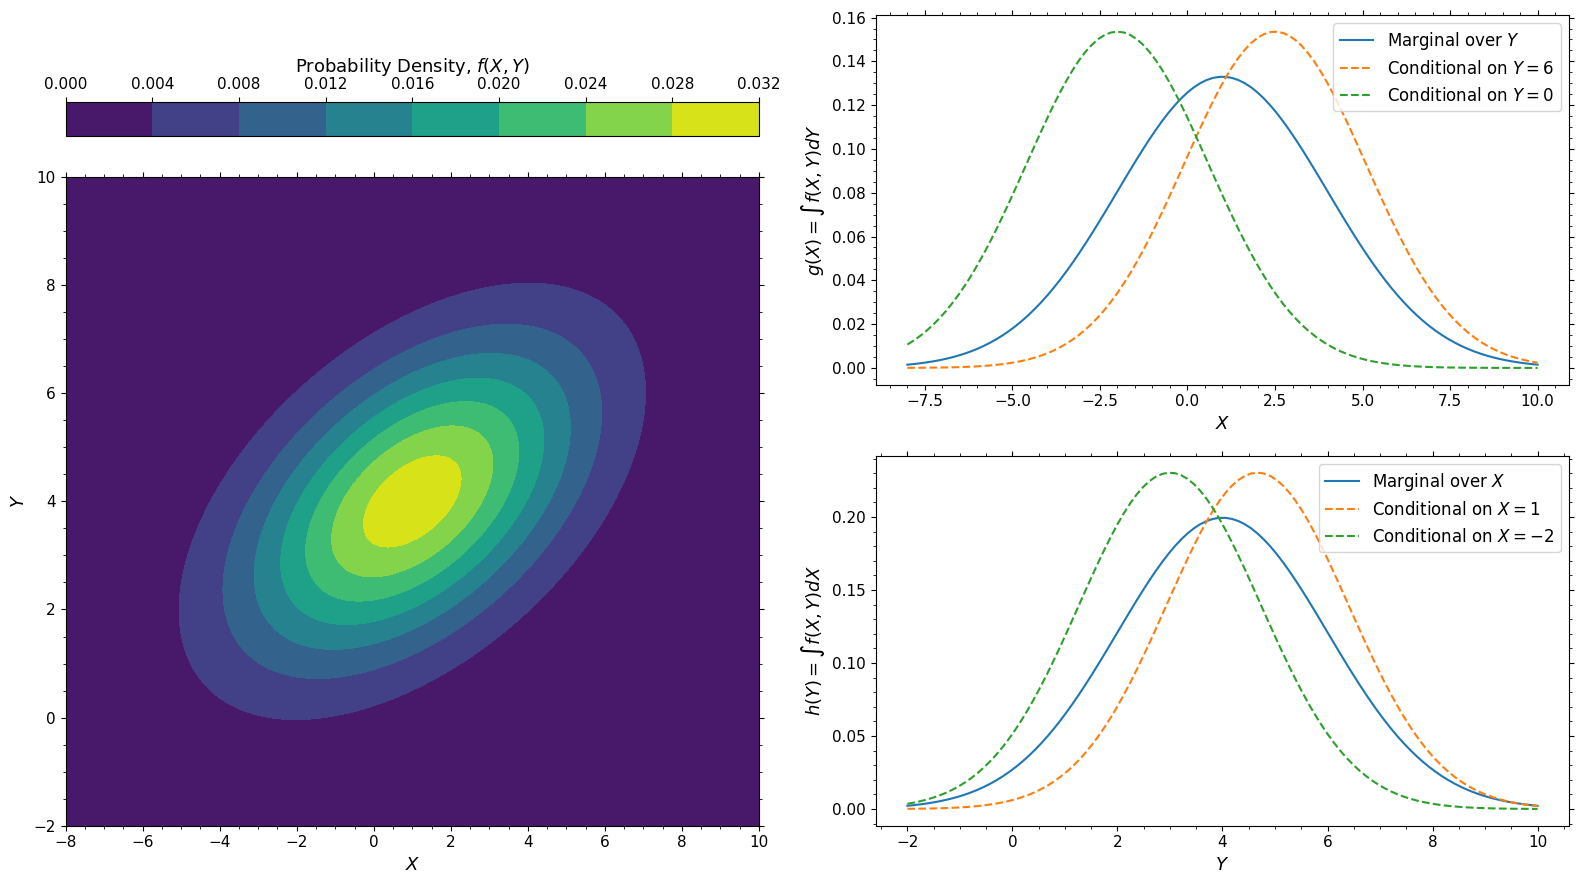

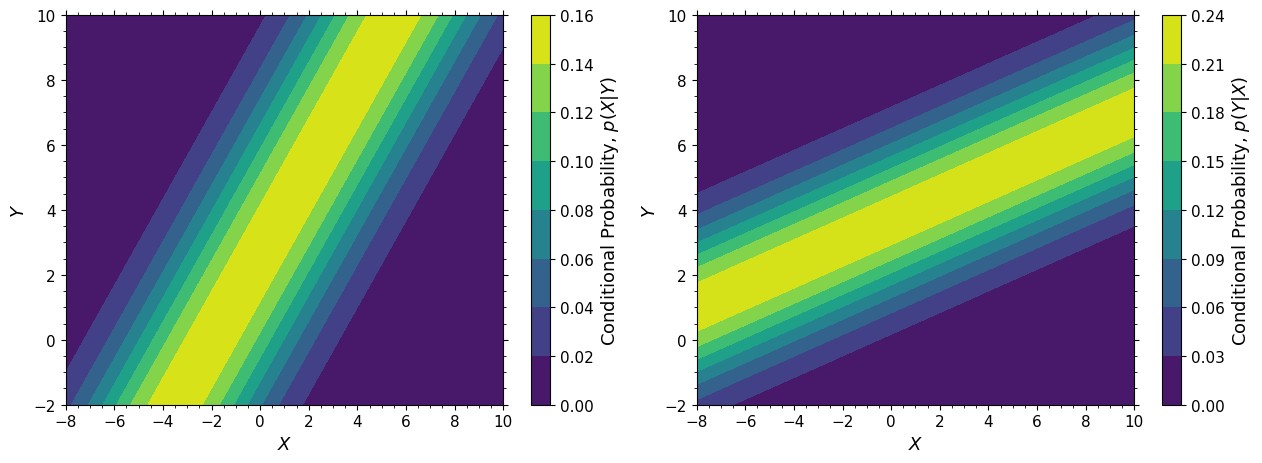

In [2]:
def get_mvn( mean, cov, marginal=None, conditional=None, verbose=False):
    """ get mvn distribution or any marginal or conditional subset of it
    
    Parameters
    ----------
    mean : array
        mu values of the multivariate normal. must be 1 dimensional.
    cov : array 
        covariance matrix of the multivariate normal. must be 2 dimensional
    marginal : int or array of int
        index or list of indices for which to marginalise over
    conditional : tuple or array of tuple
        must be a two element tuple or list of two element tuples which give (ind: val),
        the index and value which to be conditional upon
    """
    mean = np.asarray(mean)
    cov  = np.asarray(cov)
    # checks
    assert( mean.ndim==1 )
    assert( cov.ndim==2 )
    assert( mean.shape[0] == cov.shape[0] )
    assert( cov.shape[0] == cov.shape[1] )

    ndim = mean.shape[0]

    if marginal is not None:
        if np.isscalar( marginal ):
            marginal = [ marginal ]
        marginal = np.asarray( marginal )
        assert( len(marginal) < ndim )

        mmean = np.delete( mean, marginal, axis=0 )
        mcov  = np.delete( np.delete( cov, marginal, axis=0 ), marginal, axis=1 )
        
        return mvn( mmean, mcov )

    elif conditional is not None:
        conditional = np.asarray( conditional )

        argdrop = conditional[:,0].astype(np.int32)
        argkeep = np.array( [ i for i in range(ndim) if i not in argdrop ] )
        condvals = conditional[:,1]
        
        m1 = mean[argkeep] 
        m2 = mean[argdrop]

        S11 = cov[ np.ix_(argkeep, argkeep) ] 
        S22 = cov[ np.ix_(argdrop, argdrop) ]
        S12 = cov[ np.ix_(argkeep, argdrop) ] 
        S21 = cov[ np.ix_(argdrop, argkeep) ]
        
        cov_inv = np.linalg.inv( cov )
        cov1_inv = np.delete( np.delete( cov_inv, argdrop, axis=0), argdrop, axis=1 )
        cov1 = np.linalg.inv( cov1_inv )
        
        S22_inv = np.linalg.inv( S22 )

        cmean = m1 + S12 @ S22_inv @ ( condvals - m2 )
        ccov = S11 - S12 @ S22_inv @ S21
        
        return mvn( cmean, ccov )

    else:
        return mvn( mean, cov )

mu1 = 1
mu2 = 4
sg1 = 3
sg2 = 2


# 2d example
mean = np.array( [mu1,mu2] )
err  = np.array( [sg1,sg2] ).reshape( (-1,1) )
corr = np.array( [[1,0.5],[0.5,1]] )
cov  = err.T * corr * err

dist_xy = get_mvn( mean, cov )
marg_x  = get_mvn( mean, cov, marginal=1 )
marg_y  = get_mvn( mean, cov, marginal=0 )

# Make some plots 
xrange = [ mu1 - 3*sg1, mu1 + 3*sg1 ]
yrange = [ mu2 - 3*sg2, mu2 + 3*sg2 ]
x = np.linspace(*xrange,100)
y = np.linspace(*yrange,100)
X, Y = np.meshgrid(x,y)

# The 2D distribution and the 1D marginals
fig = plt.figure( figsize=(16,9) )
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot( gs[:,0] )
ax2 = fig.add_subplot( gs[0,1] )
ax3 = fig.add_subplot( gs[1,1] )
pos = np.dstack([X,Y])
Z = dist_xy.pdf(pos)
im = ax1.contourf( X, Y, Z )
cb = fig.colorbar(im, ax=ax1, location='top')
cb.set_label('Probability Density, $f(X,Y)$')
ax1.set_xlabel('$X$')
ax1.set_ylabel('$Y$')

# The 1D marginal distributions
ax2.plot( x, marg_x.pdf( x.reshape((-1,1)) ), label='Marginal over $Y$' )
ax3.plot( y, marg_y.pdf( y.reshape((-1,1)) ), label='Marginal over $X$' )
# add some 1d conditional distributions
cond_x1 = get_mvn(mean, cov, conditional=[(1,6)])
cond_x2 = get_mvn(mean, cov, conditional=[(1,0)])
ax2.plot( x, cond_x1.pdf( x.reshape((-1,1)) ), ls='--', label='Conditional on $Y=6$')
ax2.plot( x, cond_x2.pdf( x.reshape((-1,1)) ), ls='--', label='Conditional on $Y=0$')
cond_y1 = get_mvn(mean, cov, conditional=[(0,3)])
cond_y2 = get_mvn(mean, cov, conditional=[(0,-2)])
ax3.plot( y, cond_y1.pdf( y.reshape((-1,1)) ), ls='--', label='Conditional on $X=1$')
ax3.plot( y, cond_y2.pdf( y.reshape((-1,1)) ), ls='--', label='Conditional on $X=-2$')
ax2.set_xlabel('$X$')
ax2.set_ylabel('$g(X) = \int f(X,Y) dY$')
ax2.legend()
ax3.set_xlabel('$Y$')
ax3.set_ylabel('$h(Y) = \int f(X,Y) dX$')
ax3.legend()

# Now we do the 2D conditional
Z_XY = Z / marg_y.pdf( Y.reshape( (*Y.shape,1) ) )
Z_YX = Z / marg_x.pdf( X.reshape( (*X.shape,1) ) )
fig, ax = plt.subplots(1, 2, figsize=(12.8,4.8))
im = ax[0].contourf( X, Y, Z_XY )
cb = fig.colorbar(im, ax=ax[0])
cb.set_label('Conditional Probability, $p(X|Y)$')
ax[0].set_xlabel('$X$')
ax[0].set_ylabel('$Y$')
im = ax[1].contourf( X, Y, Z_YX )
cb = fig.colorbar(im, ax=ax[1])
cb.set_label('Conditional Probability, $p(Y|X)$')
ax[1].set_xlabel('$X$')
ax[1].set_ylabel('$Y$')




> ### **Question 2:**
> Show that the mean and variance of the exponential distribution with p.d.f.
> $$
p(X; \lambda) = \lambda e^{-\lambda X} 
> $$
> are given by:
>- Mean:  $\mu = \frac{1}{\lambda} $                            
> - Variance: $V(X) = \frac{1}{\lambda^2} $                

## **Solution**
### **Exponential Distribution: Mean and Variance Derivation**

The exponential probability density function (p.d.f.) is given by:

$$
p(x; \lambda) = \lambda e^{-\lambda x} \quad \text{for } x \in [0, \infty)
$$

We assume the distribution is normalized:

$$
\int_0^\infty \lambda e^{-\lambda x} \, dx = 1
$$

---

### **Mean**

To find the mean:

$$
\mu = \mathbb{E}[x] = \int_0^\infty x \lambda e^{-\lambda x} \, dx
$$

Use integration by parts:

- Let: $ u = x $, $ dv = \lambda e^{-\lambda x} dx $
- Then: $ du = dx $, $ v = -e^{-\lambda x} $

So,

$$
\mu = \int_0^\infty x \lambda e^{-\lambda x} \, dx
= \left[ -x e^{-\lambda x} \right]_0^\infty + \int_0^\infty e^{-\lambda x} \, dx
$$

Evaluating:

$$
= 0 + \left[ \frac{1}{\lambda} \right] = \frac{1}{\lambda}
$$

---

### **Variance**

To compute variance:

$$
V(x) = \mathbb{E}[(x-\mu)^2] = \mathbb{E}[x^2 - 2 x \mu + \mu^2] = \mathbb{E}[x^2] - \mu^2
$$

Compute $ \mathbb{E}[x^2] $:

$$
\mathbb{E}[x^2] = \int_0^\infty x^2 \lambda e^{-\lambda x} \, dx
$$

Use integration by parts again:

- Let: $ u = x^2 $, $ dv = \lambda e^{-\lambda x} dx $
- Then: $ du = 2x dx $, $ v = -e^{-\lambda x} $

So:

$$
\mathbb{E}[x^2] = \left[ -x^2 e^{-\lambda x} \right]_0^\infty + \int_0^\infty 2x e^{-\lambda x} dx
$$

We already know:

$$
\int_0^\infty x e^{-\lambda x} dx = \frac{1}{\lambda^2}
$$

So:

$$
\mathbb{E}[x^2] = 0 + 2 \cdot \frac{1}{\lambda^2} = \frac{2}{\lambda^2}
$$

Therefore, the variance is:

$$
\text{Var}(x) = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 = \frac{2}{\lambda^2} - \left( \frac{1}{\lambda} \right)^2 = \frac{1}{\lambda^2}
$$

> ### **Question 3:**
> Show that the mean and variance of the $ \chi^2 $ distribution with p.d.f.
> $$
p(X; k) = \frac{1}{2^{k/2} \Gamma\left(\frac{k}{2}\right)} X^{k/2 - 1} e^{-X/2} \tag{4}
> $$
> are given by:
> - Mean:  $\mu = k $                            
> - Variance: $V(X) = 2k $                     
> You may find it helpful to look up the properties of the Gamma distribution, $\Gamma(k) $.

## **Solution**
### **Chi-Squared Distribution: Mean and Variance Derivation**

The $\chi^2$ distribution probability density function (p.d.f.) is given by:

$$
p(x; k) = \frac{1}{2^{k/2} \Gamma\left( \frac{k}{2} \right)} x^{k/2 - 1} e^{-x/2}
$$

It is only defined for $x > 0$. Define the normalisation constant:

$$
N = \frac{1}{2^{k/2} \Gamma\left( \frac{k}{2} \right)}
$$

---

### **Mean**

We compute the mean $\mu = \mathbb{E}[x]$:

$$
\mu = \mathbb{E}[x] = \int_0^\infty x p(x) dx
$$

$$
= N \int_0^\infty x x^{k/2 - 1} e^{-x/2} dx
$$

$$
= N \int_0^\infty x^{k/2} e^{-x/2} dx
$$

Using integration by parts:

$$
u = x^{k/2}, \quad dv = e^{-x/2} dx
$$

$$
du = \frac{k}{2} x^{k/2 - 1} dx, \quad v = -2 e^{-x/2}
$$

Then: 

$$
\mu = \mathbb{E}[x] = N \int_0^\infty x^{k/2} e^{-x/2} dx
$$

$$
= N \left[ -2 x^{k/2} e^{-x/2} \right]_0^\infty + N \int_0^\infty 2 e^{-x/2} \cdot \frac{k}{2} x^{k/2 - 1} dx
$$

$$
= N (0 - 0) + N k \int_0^\infty x^{k/2 - 1} e^{-x/2} dx
$$

$$
= k N \int_0^\infty x^{k/2 - 1} e^{-x/2} dx
$$

But this final integral is just the integral of the distribution, so = 1:

$$
\mu = k
$$


---

### **Variance**

We now compute:

$$
\mathrm{Var}(x) = \mathbb{E}[x^2] - \mathbb{E}[x]^2
$$

We already found $\mathbb{E}[x] = k$, now compute $\mathbb{E}[x^2]$:

$$
\mathbb{E}[x^2] = \int_0^\infty x^2 p(x) dx
$$

$$
= N \int_0^\infty x^2 x^{k/2 - 1} e^{-x/2} dx
$$

$$
= N \int_0^\infty x^{k/2 + 1} e^{-x/2} dx
$$

⸻

Integration by Parts:

Let:

$$
u = x^{k/2 + 1}, \quad dv = e^{-x/2} dx
$$
$$
du = \left( \frac{k}{2} + 1 \right) x^{k/2} dx, \quad v = -2 e^{-x/2}
$$


Continuing from above:

$$
\mathbb{E}[x^2] = N \int_0^\infty x^{k/2 + 1} e^{-x/2} dx
$$

$$
= N \left[ -2 x^{k/2 + 1} e^{-x/2} \right]_0^\infty + N \int_0^\infty 2 e^{-x/2} \left( \frac{k}{2} + 1 \right) x^{k/2} dx
$$

$$
= N (0 - 0) + N (k + 2) \int_0^\infty x^{k/2} e^{-x/2} dx
$$

$$
= N (k + 2) \int_0^\infty x^{k/2} e^{-x/2} dx
$$

$$
= (k + 2)  \times N \int_0^\infty x^{k/2} e^{-x/2} dx
$$

This is the same integral as calulcated above for the mean:

$$
\mu = \mathbb{E}[x] = N \int_0^\infty x^{k/2} e^{-x/2} dx = k
$$

So, 

$$
= (k + 2)k
$$

Therefore, the Variance:

$$
\mathrm{Var}(x) = \mathbb{E}[x^2] - \mathbb{E}[x]^2
$$

$$
= k^2 + 2k - k^2 = 2k
$$


> ### **Question 4:**
> Write a simple accept-reject generator in python which can generate from an arbitary function of a random variable, f (X).

### **Quick Recap on Accept Reject Algorithm**

Rejection sampling uses a **proposal distribution** $ Q(x) $, which:
- Can be sampled from easily.
- Has support everywhere that the target distribution $ P(x) $ does.

We require that:

$$
P(x) \leq M Q(x) \quad \forall x
$$

---

### Algorithm:
1. Draw a sample $x \sim Q(x) $
2. Draw $ u \sim \mathcal{U}[0, 1] $
3. If:

$$
u < \frac{P(x)}{M Q(x)}
$$

then **accept** $ x $; otherwise, **reject** and repeat.

---

## Proof of Correctness

We aim to show:

$$
P\left(x \mid u < \frac{P(x)}{M Q(x)}\right) = P(x)
$$

---

### Step-by-step:

Using Bayes’ rule:

$$
P\left(x \mid u < \frac{P(x)}{M Q(x)}\right)
= \frac{P\left(u < \frac{P(x)}{M Q(x)} \mid x\right) \cdot P(x)}{P\left(u < \frac{P(x)}{M Q(x)}\right)}
$$

Note:

$$
P\left(u < \frac{P(x)}{M Q(x)} \mid x\right) = \frac{P(x)}{M Q(x)}
$$

So we have:

$$
P\left(x \mid u < \frac{P(x)}{M Q(x)}\right)
= \frac{\frac{P(x)}{M Q(x)} \cdot P(x)}{P\left(u < \frac{P(x)}{M Q(x)}\right)}
$$

Now compute the denominator:

$$
P\left(u < \frac{P(x)}{M Q(x)}\right)
= \int \frac{P(x)}{M Q(x)} \cdot Q(x) \, dx
= \frac{1}{M} \int P(x) \, dx = \frac{1}{M}
$$

Therefore:

$$
P\left(x \mid u < \frac{P(x)}{M Q(x)}\right)
= \left( \frac{1}{M} \right)^{-1} \cdot \frac{P(x)^2}{M Q(x)} = P(x)
$$




In [3]:
def accept_reject_1d( func, xrange, size=1, fmax=None, ret_fmax=False, seed=None, stats=False ):
    """A simple function to run accept-reject generation.

    Parameters
    ----------
    func : callable
        A callable function which accepts one argument x and 
        returns the function which you want to generate from.
        Note that for accept-reject there is no requirement
        that is normalised
    xrange : tuple or list
        Must be a two element tuple or list containing the 
        range of x values to generate in
    size : int, optional
        Number of events to generate
    fmax : float, optional
        If already known you can provide the maximum value of
        the function. This speeds up generation a bit because
        the algorithm can skip finding the maximum
    stats : bool, optional
        If True then track the generation efficiency statistics
        and return them

    Returns
    -------
    x : array
        an array of generated x values
    fmax : float, optional
        if ret_fmax=True then will also return the fmax found
    stats : tuple, optional
        if stats=True will also return the accept_eff and reject_eff

    """
    
    if fmax is None:
        print('a/r looking for fmax... ', end='')
        # global
        f_to_min = lambda x: -func(x)
        x0 = brute( f_to_min, [xrange] )[0]
        # local
        x0 = minimize( f_to_min, x0=x0, bounds=[xrange] ).x[0]
        fmax = func(x0)
        print('DONE. fmax=', fmax)

    if seed is not None:
        np.random.seed(seed)

    res = []
    nrej = 0
    while len(res)<size:

        # generate uniform random in xrange
        x = np.random.uniform(*xrange)

        # compute the value of the func at this x
        fval = func(x)

        # check it's not negative
        if fval < 0:
            raise RuntimeError(f'Accept-reject found a negative function value. p.d.f.s cannot be negative. Bailing out')

        # check it's not bigger than fmax
        if fval > fmax:
            fmax = fval
            raise RuntimeError(f'Accept-reject found a larger function value than was provided {fval}. Updating fmax and bailing out')

        # now generate random between [0, fmax]
        ftest = np.random.uniform(0, fmax )

        # if ftest larger than fval reject else accept
        if ftest <= fval:
            res.append(x)
            print(f'Accept-rejecting {len(res)} / {size}', end='\r')
        # this just counts the number of rejections
        else:
            nrej += 1
    
    if stats:
        ntot = size + nrej
        rej_eff = nrej / ntot
        acc_eff = size / ntot
    
    print('Accept-rejecting DONE         ')
    if ret_fmax:
        if stats:
            return res, fmax, acc_eff, rej_eff
        else:
            return res, fmax
    else:
        if stats:
            return res, acc_eff, rej_eff
        else:
            return res
        


def check_ok_plot( func, xrange, dset, bins='auto', save=None, title=None ):

    # going to normalise the function numerically
    N = 1/quad( func, *xrange )[0]
    
    x = np.linspace(*xrange, 100)

    fig, ax = plt.subplots()
    ax.hist( dset, density=True, bins=bins, label='Generated sample')
    ax.plot(x, N*func(x), label='Function')
    ax.set_xlabel('$X$')
    ax.set_ylabel('Probability Density')
    ax.legend()
    
    if title is not None:
        ax.set_title( title )


> ### **Question 4(a):**
> Generate some samples for the following distributions:
> $$
f(x) = cos^2(x)
> $$

a/r looking for fmax... DONE. fmax= 1.0
Accept-rejecting DONE         


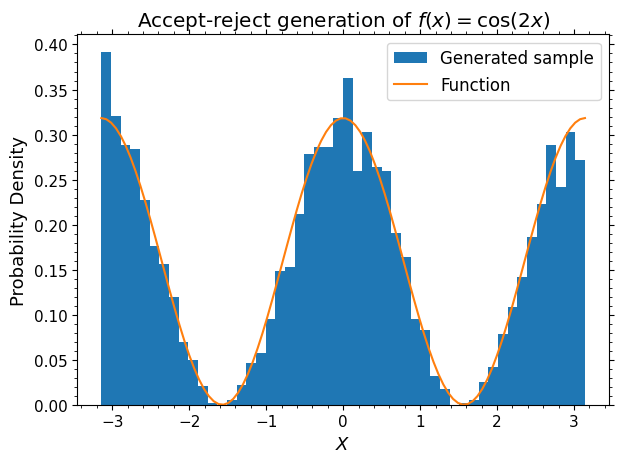

In [4]:
# Limits of the x-axis for the accept-reject generation
xrange = [-np.pi, np.pi]
# function to generate from
cos2x = lambda x: np.cos(x)**2
# Names for the plots
names = r'$f(x) = \cos^2(x)$'

# Run accept-reject generation
dset = accept_reject_1d( cos2x, xrange, size=5000)
# Plot the results
check_ok_plot( cos2x, xrange, dset, bins=50, title='Accept-reject generation of $f(x) = \cos(2x)$')
                        

> ### **Question 4(b):**
> Generate some samples for the following distributions:
> $$
f(x) = sin(x) + cos(x) + 2
> $$

a/r looking for fmax... DONE. fmax= 3.414213562373095
Accept-rejecting DONE         


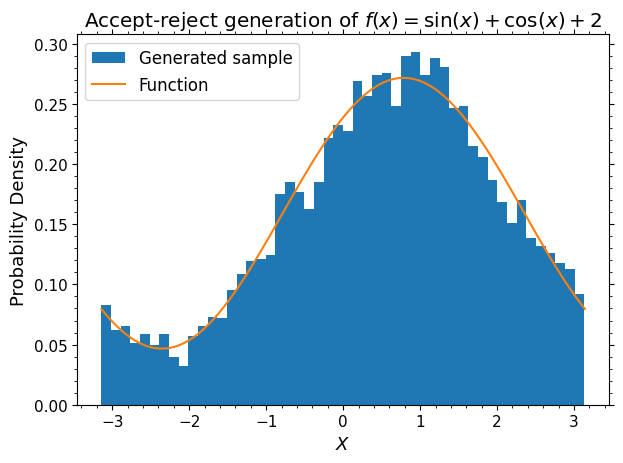

In [5]:
# Limits of the x-axis for the accept-reject generation
xrange = [-np.pi, np.pi]
# function to generate from
cos2x = lambda x: np.sin(x) + np.cos(x) + 2
# Names for the plots
names = r'$f(x) = \sin(x) + \cos(x) + 2$'

# Run accept-reject generation
dset = accept_reject_1d( cos2x, xrange, size=5000)
# Plot the results
check_ok_plot( cos2x, xrange, dset, bins=50, title='Accept-reject generation of $f(x) = \sin(x) + \cos(x) + 2$')

> ### **Question 4(c):**
> Generate some samples for the following distributions:
> $$
f(x) = \frac{sin(x)+cos(x)}{sinh(x)+cosh(x)} + 25
> $$

a/r looking for fmax... DONE. fmax= 26.0
Accept-rejecting DONE         


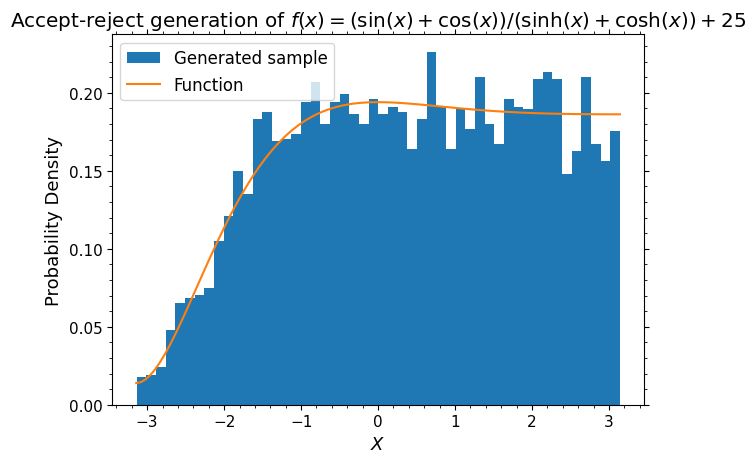

In [6]:
# Limits of the x-axis for the accept-reject generation
xrange = [-np.pi, np.pi]
# function to generate from
cos2x = lambda x: ( np.sin(x) + np.cos(x) ) / ( np.sinh(x) + np.cosh(x) ) + 25
# Names for the plots
names = r'$f(x) = ( \sin(x) + \cos(x) ) / ( \sinh(x) + \cosh(x) ) + 25$'

# Run accept-reject generation
dset = accept_reject_1d( cos2x, xrange, size=5000)
# Plot the results
check_ok_plot( cos2x, xrange, dset, bins=50, title='Accept-reject generation of $f(x) = ( \sin(x) + \cos(x) ) / ( \sinh(x) + \cosh(x) ) + 25$')

### **A quick discussion on efficiency**:

a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327
Accept-rejecting DONE         
a/r looking for fmax... DONE. fmax= 0.3989422804014327

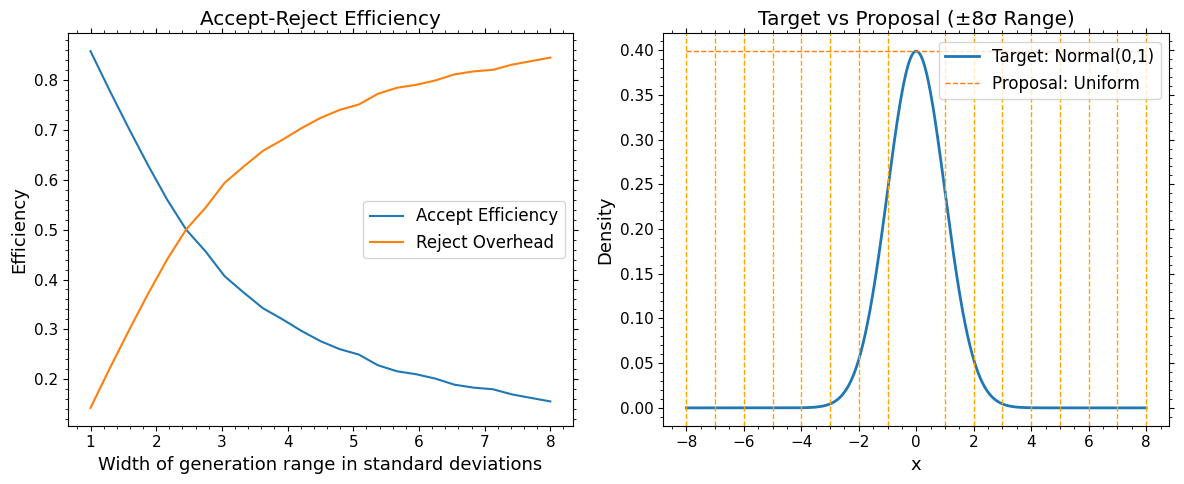

In [7]:
# Define target function (standard normal PDF)
target_func = lambda x: (1/np.sqrt(2*np.pi)) * np.exp(-x**2 / 2)

# Efficiency calculation
acc_effs = []
rej_effs = []
sigmas = np.linspace(1, 8, 25)
for sigma in sigmas:
    xrange = [-sigma, sigma]
    _, acc_eff, rej_eff = accept_reject_1d(target_func, xrange, size=10000, stats=True)
    acc_effs.append(acc_eff)
    rej_effs.append(rej_eff)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: efficiency vs sigma
ax1.plot(sigmas, acc_effs, label='Accept Efficiency')
ax1.plot(sigmas, rej_effs, label='Reject Overhead')
ax1.set_xlabel('Width of generation range in standard deviations')
ax1.set_ylabel('Efficiency')
ax1.set_title('Accept-Reject Efficiency')
ax1.legend()

# Right: Proposal vs Target for 8-sigma range
sigma = 8
x_vals = np.linspace(-sigma, sigma, 1000)
y_target = target_func(x_vals)
y_proposal = np.ones_like(x_vals) * max(y_target)

ax2.plot(x_vals, y_target, label='Target: Normal(0,1)', lw=2)
ax2.plot(x_vals, y_proposal, label='Proposal: Uniform', linestyle='--',  linewidth=1)

# Add vertical lines for ±1σ to ±8σ
for s in range(1, sigma+1):
    ax2.axvline(x=s, color='orange', linestyle='--', linewidth=1)
    ax2.axvline(x=-s, color='orange', linestyle='--', linewidth=1)

ax2.set_title('Target vs Proposal (±8σ Range)')
ax2.set_xlabel('x')
ax2.set_ylabel('Density')
ax2.legend(loc='upper right')

plt.tight_layout()


> ## **Question 5:**

#### **A quick outline of the propogation of errors for non linear functions $y = f(x)$:**

Using a Taylor expansion about $ x_0 $:

$$
f(x) \approx f(x_0) + (x - x_0) \left( \frac{df}{dx} \right)_{x = x_0} + \mathcal{O}(x^2)
$$

Variance propagation:

$$
\text{Var}(y) = \left( \frac{dy}{dx} \right)^2 \text{Var}(x)
$$

Standard deviation:

$$
\sigma_y = \left| \frac{dy}{dx} \right| \sigma_x
$$

> **Assumes small errors**.

---

### **Case of Two Variables: $ f(x, y) $**

General formula using partial derivatives:

$$
\text{Var}(f) = \left( \frac{\partial f}{\partial x} \right)^2 \text{Var}(x)
+ \left( \frac{\partial f}{\partial y} \right)^2 \text{Var}(y)
+ 2 \left( \frac{\partial f}{\partial x} \right) \left( \frac{\partial f}{\partial y} \right) \text{Cov}(x, y)
$$

Alternatively using standard deviations:

$$
\sigma_f^2 = \left( \frac{\partial f}{\partial x} \right)^2 \sigma_x^2
+ \left( \frac{\partial f}{\partial y} \right)^2 \sigma_y^2
+ 2 \left( \frac{\partial f}{\partial x} \right) \left( \frac{\partial f}{\partial y} \right) \rho \sigma_x \sigma_y
$$

> ## **Question 5(a):**
> Using the Jacobian matrix, derive the standard error propagation formula for $\sigma_f$ given $\sigma_x$ and $\sigma_y$ for the following transformations:
> $$
f = x + y
> $$
> - Assume that $x$ and $y$ are independent.

## **Solution**:
- Independent x and y 
    -  $\rho = 0$
$$
\sigma_f^2 = \left( \frac{\partial f}{\partial x} \right)^2 \sigma_x^2
+ \left( \frac{\partial f}{\partial y} \right)^2 \sigma_y^2
$$
--- 

$$
\frac{\partial f}{\partial x} = 1 \quad \text{and} \quad \frac{\partial f}{\partial y} = 1
$$
$$
\Rightarrow \sigma_f^2 = \sigma_x^2 + \sigma_y^2
$$



> ### **Question 5(b):**
> Using the Jacobian matrix, derive the standard error propagation formula for $\sigma_f$ given $\sigma_x$ and $\sigma_y$ for the following transformations:
> $$
f = xy
> $$
> - Assume that $x$ and $y$ are independent.

## **Solution**:
- Independent x and y 
    -  $\rho = 0$
$$
\sigma_f^2 = \left( \frac{\partial f}{\partial x} \right)^2 \sigma_x^2
+ \left( \frac{\partial f}{\partial y} \right)^2 \sigma_y^2
$$
--- 


$$
\frac{\partial f}{\partial x} = y \quad \text{and} \quad \frac{\partial f}{\partial y} = x
$$

$$
\Rightarrow \sigma_f^2 = y^2 \sigma_x^2 + x^2 \sigma_y^2
$$

$$
\Rightarrow \left( \frac{\sigma_f}{f} \right)^2 = \left( \frac{\sigma_x}{x} \right)^2 + \left( \frac{\sigma_y}{y} \right)^2
$$

> ### **Question 5(c):**
> Using the Jacobian matrix, derive the standard error propagation formula for $\sigma_f$ given $\sigma_x$ and $\sigma_y$ for the following transformations:
> $$
f = \dfrac{x}{y}
> $$
> - Assume that $x$ and $y$ are independent.

## **Solution**:
- Independent x and y 
    -  $\rho = 0$
$$
\sigma_f^2 = \left( \frac{\partial f}{\partial x} \right)^2 \sigma_x^2
+ \left( \frac{\partial f}{\partial y} \right)^2 \sigma_y^2
$$
--- 


$$
\frac{\partial f}{\partial x} = \frac{1}{y} \quad \text{and} \quad \frac{\partial f}{\partial y} = -\frac{x}{y^2}
$$
$$
\Rightarrow \sigma_f^2 = \frac{1}{y^2} \sigma_x^2 + \frac{x^2}{y^4} \sigma_y^2
$$
$$
\Rightarrow \left( \frac{\sigma_f}{f} \right)^2 = \left( \frac{\sigma_x}{x} \right)^2 + \left( \frac{\sigma_y}{y} \right)^2
$$

> ### **Question 5(d):**
> Using the Jacobian matrix, derive the standard error propagation formula for $\sigma_f$ given $\sigma_x$ and $\sigma_y$ for the following transformations:
> $$
f = \sin(x)
> $$

## **Solution**:
- Single Variable
$$
\sigma_f^2 = \left( \frac{\partial f}{\partial x} \right)^2 \sigma_x^2
$$
--- 

$$
\frac{\partial f}{\partial x} = \cos(x)
$$
$$
\Rightarrow \sigma_f^2 = \cos^2(x) \sigma_x^2
$$

> ### **Question 5(e):**
> Using the Jacobian matrix, derive the standard error propagation formula for $\sigma_f$ given $\sigma_x$ and $\sigma_y$ for the following transformations:
> $$
f = \cos(x)
> $$

## **Solution**:
- Single Variable
$$
\sigma_f^2 = \left( \frac{\partial f}{\partial x} \right)^2 \sigma_x^2
$$
--- 

$$
\frac{\partial f}{\partial x} = -\sin(x)
$$
$$
\Rightarrow \sigma_f^2 = \sin^2(x) \sigma_x^2
$$

> ### **Question 6:**
> Using the minimum variance bound, show that the sample mean, $\bar{X}$, is an efficient estimate of the distribution mean, $\mu$. It is simplest to use the assumption that the sample is normally distributed.

## **Solution**
#### **Defining an Efficient Estimator:**

An estimator $ \hat{\theta} $ is said to be **efficient** if its variance achieves the **minimum variance bound**, which is the the negative inverse of the expectation of the double differential of the log-likelihood (**Cramér-Rao lower bound**):

Thus we must show that the following holds: 

$$
V(\hat{\theta}) = -\mathbb{E} \left[ \frac{\partial^2 \ln L}{\partial \theta^2} \right]^{-1}
$$


---

### **For the Normal Distribution:**

The p.d.f. is given by:

$$
p(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi} \sigma} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)
\tag{65}
$$

---

### **Log-Likelihood Function (for $ N $ observations):**

$$
\ln L = \ln \left( \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi} \sigma} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right) \right)
$$

$$
= \sum_{i=1}^{N} \ln \left( \frac{1}{\sqrt{2\pi} \sigma} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right) \right)
$$

$$
= -N \ln(\sqrt{2\pi} \sigma) - \sum_{i=1}^{N} \frac{(x_i - \mu)^2}{2\sigma^2}
$$

---

### **Differentiating Twice with Respect to  $ \mu $:**

First derivative:

$$
\frac{\partial}{\partial \mu} \left( \ln L \right)
= \frac{\partial}{\partial \mu} \left( -\sum_{i=1}^{N} \frac{(x_i - \mu)^2}{2\sigma^2} \right)
$$

$$
= \sum_{i=1}^{N} \frac{(x_i - \mu)}{\sigma^2}
$$

$$
= \frac{1}{\sigma^2} \left( \sum_{i=1}^{N} (x_i - \mu) \right)
$$

Second derivative:

$$
\frac{\partial^2}{\partial \mu^2} \left( \ln L \right) = -\frac{N}{\sigma^2}
$$

Thus, the expectation over x (no dependence):

$$
\mathbb{E} \left[ \frac{\partial^2 \ln L}{\partial \mu^2} \right] = -\frac{N}{\sigma^2}
$$

---

### **Minimum Variance Bound:**

$$
\Rightarrow V(\hat{\mu}) = \left( -\mathbb{E} \left[ \frac{\partial^2 \ln L}{\partial \mu^2} \right] \right)^{-1} = \frac{\sigma^2}{N}
$$

From the **Central Limit Theorem**, the variance of the sample mean is also:

$$
V(\bar{x}) = \frac{\sigma^2}{N}
$$



> ### **Question 7:**
> Use the maximum likelihood method to mathematically show that an estimate for the lifetime, $\tau$, of a decay-time distribution, $(1/\tau)e^{-t/\tau}$, is given by the average of the observed decay times, $t$.

The p.d.f. for an exponential distribution is often expressed in terms of the parameter $ \lambda $, but can also be written in terms of the average lifetime $ \tau = \frac{1}{\lambda} $. Thus, we have:

$$
p(t; \lambda) = \lambda e^{-\lambda t}
\quad \Longleftrightarrow \quad
p(t; \tau) = \frac{1}{\tau} e^{-t / \tau}
$$

where decay times must be positive, so the p.d.f. is only valid for $ t \geq 0 $. One can verify the proper normalization if needed.

---

### **Log-Likelihood over $ N $ observations**

Let's compute the log-likelihood:

$$
\ln L = \ln \left( \prod_{i=1}^{N} \frac{1}{\tau} e^{-t_i / \tau} \right)
$$

$$
= \sum_{i=1}^{N} \ln \left( \frac{1}{\tau} e^{-t_i / \tau} \right)
$$

$$
= \sum_{i=1}^{N} \left[ \ln \left( \frac{1}{\tau} \right) - \frac{t_i}{\tau} \right]
$$

---

### **Differentiate with respect to $ \tau $:**

$$
\frac{d \ln L}{d\tau} = \frac{N}{\tau} - \sum_{i=1}^{N} \frac{t_i}{\tau^2}
$$

To find the maximum of the log-likelihood, set the derivative to zero:

$$
\frac{N}{\tau} - \sum_{i=1}^{N} \frac{t_i}{\tau^2} = 0
$$

$$
\Rightarrow \frac{1}{\tau} \sum_{i=1}^{N} t_i = N
$$

$$
\Rightarrow \hat{\tau} = \frac{1}{N} \sum_{i=1}^{N} t_i
$$

This is simply the **average of the observed decay times**, which makes intuitive sense.

> ### **Question 8:**
> Show that when fitting a straight line to pairs of points $(x_i, y_i)$ with the least squares method, the estimates of the slope and intercept are given by:
> - $\hat{c} = \bar{y} - \hat{m} \bar{x}$
> - $m = \text{cov}(x, y)/V(x)$

## **Solution:**

We have no uncertainties in this case so can set all $ \sigma_i = 1 $. Thus the $ \chi^2 $ in this case is given as:

$$
\chi^2 = \sum_{i=1}^{N} \frac{(y_i - mx_i - c)^2}{\sigma_i^2}
$$

$$
= \sum_{i=1}^{N} (y_i - mx_i - c)^2
$$

---

To find the minimum (i.e., least-squares estimate) of the parameters $ m $ or $ c $, we differentiate with respect to $ m $ or $ c $ and set to zero:

$$
\frac{\partial \chi^2}{\partial m} = -2 \sum x_i (y_i - mx_i - c)
$$

$$
= -2 (\overline{xy} - m\overline{x^2} - c\overline{x})
$$

$$
\frac{\partial \chi^2}{\partial c} = -2 \sum (y_i - mx_i - c)
$$

$$
= -2 (\overline{y} - m\overline{x} - c)
$$

---

Now set differentials to zero and solve to find the estimates, $ \hat{m} $ and $ \hat{c} $:

1.  
$$
\overline{xy} - \hat{m} \overline{x^2} - \hat{c} \overline{x} = 0
$$

2.  
$$
\overline{y} - \hat{m} \overline{x} - \hat{c} = 0
$$

---

The second equation gives:

$$
\hat{c} = \overline{y} - \hat{m} \overline{x}
$$

We can plug this into the first equation and solve for $ \hat{m} $:

$$
0 = \overline{xy} - \hat{m} \overline{x^2} - \hat{c} \overline{x}
$$

$$
= \overline{xy} - \hat{m} \overline{x^2} - \overline{x} (\overline{y} - \hat{m} \overline{x})
$$

$$
= \overline{xy} - \overline{x} \overline{y} - \hat{m} (\overline{x^2} - \overline{x}^2)
$$

So:

$$
\hat{m} = \frac{\overline{xy} - \overline{x} \, \overline{y}}{\overline{x^2} - \overline{x}^2}
$$

$$
= \frac{\text{Cov}(x,y)}{V(x)}
$$

---

We can also plug this expression for $ \hat{m} $ back into the equation for $ \hat{c} $ to eliminate dependence on $ \hat{m} $:

$$
\hat{c} = \frac{\overline{x^2} \, \overline{y} - \overline{x} \, \overline{xy}}{\overline{x^2} - \overline{x}^2}
$$